<a href="https://colab.research.google.com/github/annapurna-tumu6080/California-Housing-ML-Project/blob/main/California_Housing_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2.loading the data

In [64]:

train_df = pd.read_csv('/content/sample_data/california_housing_train.csv')
print("Data Dimensions(Rows,Columns):",train_df.shape)
train_df.head()

Data Dimensions(Rows,Columns): (17000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


3.understanding the data

In [67]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [68]:
train_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


4.checking missing values

In [69]:
train_df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


5. Correlation Analysis (EDA)

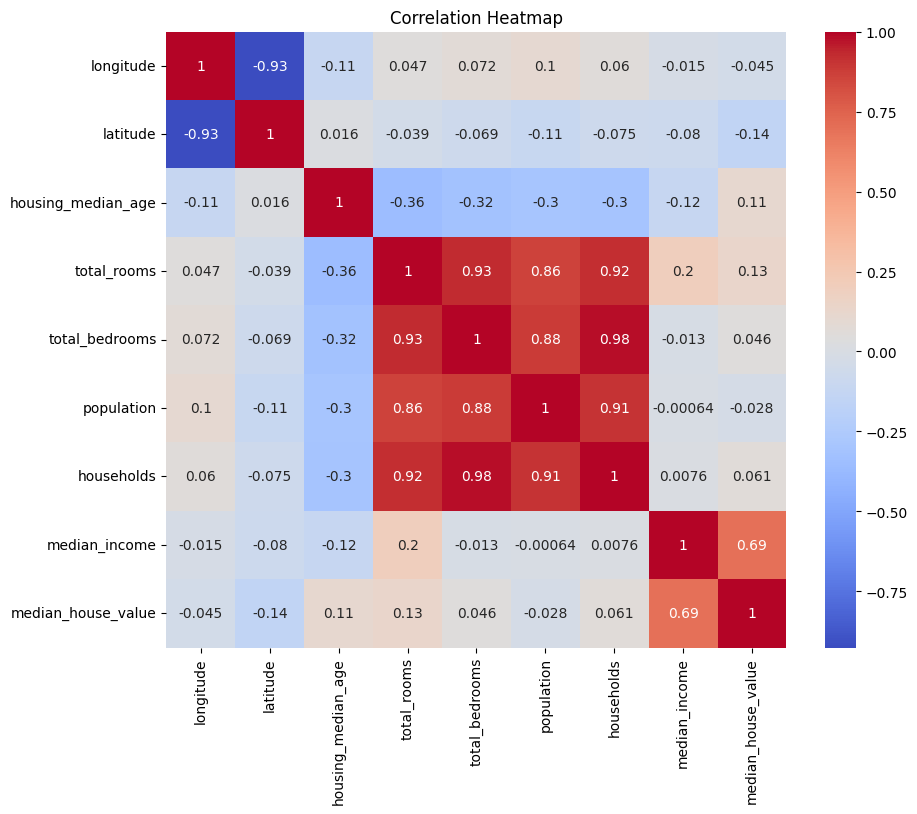

In [74]:
plt.figure(figsize=(10,8))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

6.separating features and targets

In [70]:
X= train_df.drop(columns=['median_house_value'])
y = train_df['median_house_value']
print("Features shape :",X.shape)
print("Labels shape: ",y.shape)


Features shape : (17000, 8)
Labels shape:  (17000,)


7.slpiting train and test data

In [71]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)
print(X_train.shape)
print(X_test.shape)

(13600, 8)
(3400, 8)


8.Training Linear regression model

In [72]:
from sklearn.linear_model import LinearRegression
#Create the model factory
model = LinearRegression()
#Train the model
model.fit(X_train,y_train)
predictions = model.predict(X_test)
print("Model training complete! .")

Model training complete! .


9.Evaluate Linear Regression Model

In [73]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 49983.47465122931
MSE: 4634658406.223264
R2 Score: 0.6636396350243869


10.Visualize Actual vs Predicted

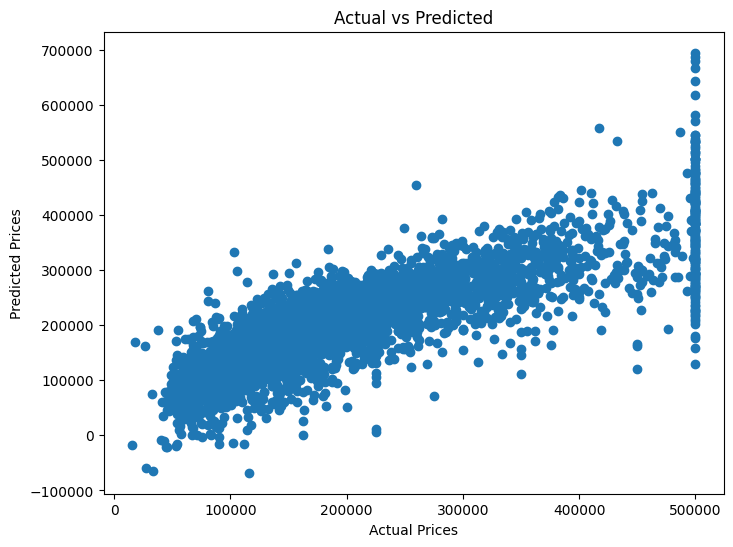

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

11.Improve with
Random Forest

In [76]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


R2 Score: 0.822786541134775
Random forest training complete


12. Evaluate Random Forest

In [79]:

print("R2 Score:", r2_score(y_test, rf_pred))
print("Random forest training complete")

R2 Score: 0.822786541134775
Random forest training complete


13.Comparing models: Linear Regression vs Random Forest

In [77]:

print("Linear Regression R2:", r2)

rf_r2 = r2_score(y_test, rf_pred)
print("Random Forest R2:", rf_r2)


Linear Regression R2: 0.6636396350243869
Random Forest R2: 0.822786541134775
